### Imports & Daten laden

In [139]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [140]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [141]:
# Daten laden
train_path = "data-science-competition-dscb-ss-26/train.csv"
test_path = "data-science-competition-dscb-ss-26/test.csv"
sample_submission_path = "data-science-competition-dscb-ss-26/sample_submission.csv"
output_path = "submission.csv"

train = pd.read_csv(train_path, parse_dates=["date"])
test  = pd.read_csv(test_path,  parse_dates=["date"])
sample_submission = pd.read_csv(sample_submission_path)

# Kalender-Features
for df in [train, test]:
    df["month"]   = df["date"].dt.month
    df["weekday"] = df["date"].dt.weekday

# Lag-Features pro Station (Zeitreihe muss sortiert sein!)
# Train und Test zusammenhängen, damit die Lags an der Grenze korrekt sind
train["_split"] = "train"
test["_split"]  = "test"

combined = pd.concat([train, test], ignore_index=True)
combined = combined.sort_values(["station", "date"]).reset_index(drop=True)

for lag in [1, 2, 7]:
    combined[f"pm25_lag{lag}"] = (
        combined.groupby("station")["pm25"].shift(lag)
    )

# Rolling 7-Tage-Mittel (min_periods=1 damit keine NaNs durch kurze Anfangsperiode)
combined["pm25_roll7"] = (
    combined.groupby("station")["pm25"]
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

# Wieder trennen
train = combined[combined["_split"] == "train"].drop(columns="_split").reset_index(drop=True)
test  = combined[combined["_split"] == "test"].drop(columns="_split").reset_index(drop=True)

print("Train:", train.shape, "  Test:", test.shape)
print("Neue Features:", ["pm25_lag1", "pm25_lag2", "pm25_lag7", "pm25_roll7"])

Train: (14319, 21)   Test: (2845, 21)
Neue Features: ['pm25_lag1', 'pm25_lag2', 'pm25_lag7', 'pm25_roll7']


### EDA

In [142]:
# Überblick: Datentypen und Datumsbereich
print("=== Erste Zeilen ===")
display(train.head())

print("\n=== Datentypen ===")
print(train.dtypes)

print("\n=== Datumsbereich ===")
print("Train:", train["date"].min().date(), "bis", train["date"].max().date())
print("Test: ", test["date"].min().date(),  "bis", test["date"].max().date())

=== Erste Zeilen ===


,id,station,date,pm25,pm10,so2,no2,co,o3,temp,...,dewp,rain,wd,wspm,month,weekday,pm25_lag1,pm25_lag2,pm25_lag7,pm25_roll7
0,Aotizhongxin_2013-03-01,Aotizhongxin,2013-03-01,7.125000,10.750000,11.708333,22.583333,429.166667,63.875000,1.391667,...,-18.745833,0.0,N,3.254167,3,4,NaN,NaN,NaN,NaN
1,Aotizhongxin_2013-03-02,Aotizhongxin,2013-03-02,30.750000,42.083333,36.625000,66.666667,824.916667,29.750000,0.616667,...,-15.937500,0.0,NE,1.479167,3,5,7.125000,NaN,NaN,7.125000
2,Aotizhongxin_2013-03-03,Aotizhongxin,2013-03-03,76.916667,120.541667,61.291667,81.000000,1620.625000,19.125000,5.566667,...,-12.316667,0.0,NNE,1.658333,3,6,30.750000,7.125000,NaN,18.937500
3,Aotizhongxin_2013-03-04,Aotizhongxin,2013-03-04,22.708333,44.583333,22.869565,46.956522,617.391304,53.750000,9.962500,...,-11.683333,0.0,N,2.404167,3,0,76.916667,30.750000,NaN,38.263889
4,Aotizhongxin_2013-03-05,Aotizhongxin,2013-03-05,148.875000,183.791667,93.875000,132.833333,2357.958333,68.458333,6.291667,...,-7.525000,0.0,NE,1.129167,3,1,22.708333,76.916667,NaN,34.375000



=== Datentypen ===
id                       str
station                  str
date          datetime64[us]
pm25                 float64
pm10                 float64
so2                  float64
no2                  float64
co                   float64
o3                   float64
temp                 float64
pres                 float64
dewp                 float64
rain                 float64
wd                       str
wspm                 float64
month                  int32
weekday                int32
pm25_lag1            float64
pm25_lag2            float64
pm25_lag7            float64
pm25_roll7           float64
dtype: object

=== Datumsbereich ===
Train: 2013-03-01 bis 2016-06-30
Test:  2016-07-01 bis 2017-02-28


In [143]:
# Fehlende Werte pro Spalte
nan_train = pd.DataFrame({
    "fehlend": train.isnull().sum(),
    "Anteil %": (train.isnull().sum() / len(train) * 100).round(1)
})
nan_test = pd.DataFrame({
    "fehlend": test.isnull().sum(),
    "Anteil %": (test.isnull().sum() / len(test) * 100).round(1)
})

print("=== Fehlende Werte – Train ===")
display(nan_train[nan_train["fehlend"] > 0])

print("\n=== Fehlende Werte – Test ===")
display(nan_test[nan_test["fehlend"] > 0])

# CO hat mit ~4.4 % die höchste Fehlrate – wird per Median-Imputation behandelt

=== Fehlende Werte – Train ===


,fehlend,Anteil %
so2,121,0.8
no2,233,1.6
co,632,4.4
o3,279,1.9
temp,1,0.0
pres,1,0.0
dewp,1,0.0
wd,4,0.0
pm25_lag1,12,0.1
pm25_lag2,24,0.2



=== Fehlende Werte – Test ===


,fehlend,Anteil %
pm25,2845,100.0
so2,10,0.4
no2,14,0.5
co,33,1.2
o3,33,1.2
wd,5,0.2
pm25_lag1,2833,99.6
pm25_lag2,2821,99.2
pm25_lag7,2761,97.0
pm25_roll7,2761,97.0


=== PM2.5 Statistik ===
count    14319.0
mean        78.8
std         66.9
min          3.0
25%         30.5
50%         60.3
75%        107.4
max        567.4
Name: pm25, dtype: float64


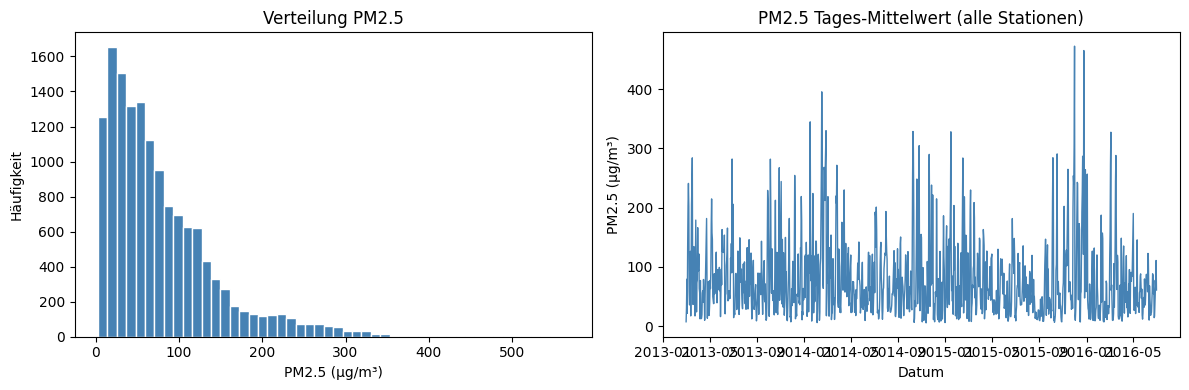

In [144]:
# Zielvariable PM2.5 – Verteilung und Zeitverlauf
print("=== PM2.5 Statistik ===")
print(train["pm25"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramm
axes[0].hist(train["pm25"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Verteilung PM2.5")
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].set_ylabel("Häufigkeit")

# Zeitreihe (Mittelwert über alle Stationen)
daily_mean = train.groupby("date")["pm25"].mean()
axes[1].plot(daily_mean.index, daily_mean.values, lw=1, color="steelblue")
axes[1].set_title("PM2.5 Tages-Mittelwert (alle Stationen)")
axes[1].set_xlabel("Datum")
axes[1].set_ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

# Beobachtung: PM2.5 ist rechtschief – viele niedrige Werte, Extremwerte bis ~570
# Deutliche Saisonalität: Winter (Okt–Feb) höher als Sommer

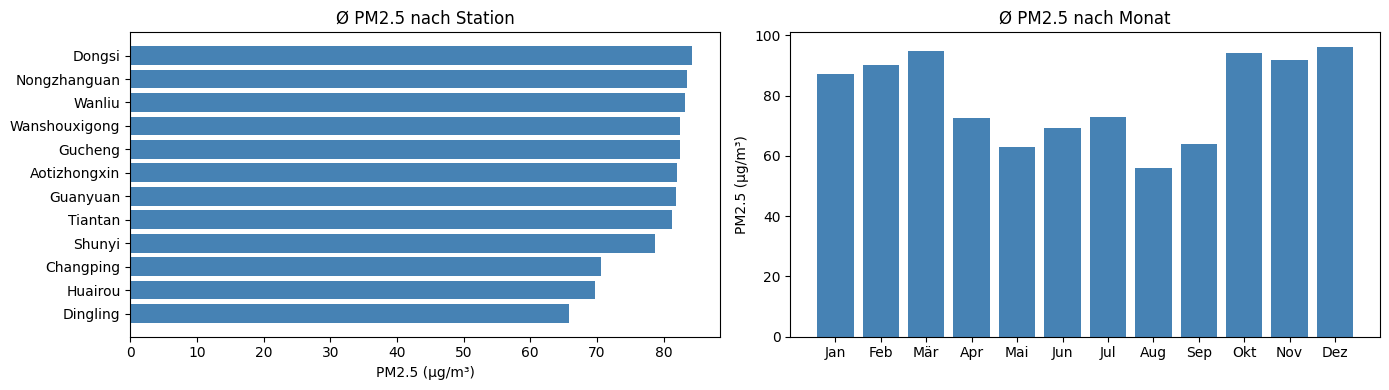

In [145]:
# PM2.5 nach Station und Monat
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Nach Station
pm_station = train.groupby("station")["pm25"].mean().sort_values(ascending=False)
axes[0].barh(pm_station.index, pm_station.values, color="steelblue")
axes[0].set_title("Ø PM2.5 nach Station")
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].invert_yaxis()

# Nach Monat
pm_month = train.groupby(train["date"].dt.month)["pm25"].mean()
month_names = ["Jan","Feb","Mär","Apr","Mai","Jun","Jul","Aug","Sep","Okt","Nov","Dez"]
axes[1].bar(pm_month.index, pm_month.values, color="steelblue")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title("Ø PM2.5 nach Monat")
axes[1].set_ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

# Innenstadtstationen (Dongsi, Nongzhanguan) systematisch höher als Randstationen (Dingling, Huairou)
# Winter deutlich stärker belastet als Sommer

### Datenbereinigung

In [146]:
# Datenbereinigung – Prüfung und Dokumentation der Entscheidungen
print("Negative PM2.5-Werte:  ", (train["pm25"] < 0).sum())
print("Duplikate (id):        ", train["id"].duplicated().sum())
print("PM2.5 Ausreißer ≥ 300: ", (train["pm25"] >= 300).sum(), "Einträge (werden behalten)")
print("PM2.5 Minimum:         ", train["pm25"].min(), "→ Clip-Grenze für Vorhersagen")

# Entscheidungen:
# - Numerische NaNs → Median-Imputation (robust gegenüber Ausreißern)
# - Kategorische NaNs (wd: 4 Einträge) → häufigster Wert
# - Ausreißer PM2.5 ≥ 300 → behalten (echte Extremereignisse, keine Messfehler)
# - Imputation passiert im Preprocessor der Modell-Pipeline (nächster Schritt)

Negative PM2.5-Werte:   0
Duplikate (id):         0
PM2.5 Ausreißer ≥ 300:  167 Einträge (werden behalten)
PM2.5 Minimum:          3.0 → Clip-Grenze für Vorhersagen


In [147]:
# Feature-Liste
categorical_features = ["station", "wd"]
numeric_features = [
    "pm10", "so2", "no2", "co", "o3",
    "temp", "pres", "dewp", "rain", "wspm",
    "month", "weekday",
]
feature_columns = categorical_features + numeric_features

In [148]:
# Validation Split
# Validation Split – Winter im Validierungszeitraum
validation_start = pd.Timestamp("2015-10-01")
validation_end   = pd.Timestamp("2016-02-29")

fit_mask   = train["date"] < validation_start
valid_mask = (train["date"] >= validation_start) & (train["date"] <= validation_end)

X_fit   = train.loc[fit_mask,   feature_columns]
y_fit   = train.loc[fit_mask,   "pm25"]
X_valid = train.loc[valid_mask, feature_columns]
y_valid = train.loc[valid_mask, "pm25"]

print("X_fit:", X_fit.shape, "  X_valid:", X_valid.shape)
print("Validierungszeitraum:", train.loc[valid_mask, "date"].min().date(),
      "bis", train.loc[valid_mask, "date"].max().date())

X_fit: (11084, 14)   X_valid: (1801, 14)
Validierungszeitraum: 2015-10-01 bis 2016-02-29


In [149]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ]
)

In [150]:
# Linear Baseline
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])
linear_model.fit(X_fit, y_fit)
linear_valid_pred = linear_model.predict(X_valid)
linear_valid_mse  = mean_squared_error(y_valid, linear_valid_pred)

In [151]:
regularized_linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge()),
])

In [152]:
# Regularisierte Suche
regularized_linear_search = RandomizedSearchCV(
    estimator=regularized_linear_pipeline,
    param_distributions=[
        {"regressor": [Ridge()],      "regressor__alpha": [0.01, 0.1, 1.0, 10.0]},
        {"regressor": [Lasso(max_iter=10000)], "regressor__alpha": [0.01, 0.1, 1.0, 10.0]},
        {"regressor": [ElasticNet(max_iter=10000)],
         "regressor__alpha": [0.01, 0.1, 1.0, 10.0],
         "regressor__l1_ratio": [0.2, 0.5, 0.8]},
    ],
    n_iter=25,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_mean_squared_error",
    random_state=42, n_jobs=1,
)
regularized_linear_search.fit(X_fit, y_fit)

c:\Users\Hagen\miniconda3\envs\py312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 20 is smaller than n_iter=25. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Ridge())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'regressor': [Ridge()], 'regressor__alpha': [0.01, 0.1, ...]}, {'regressor': [Lasso(max_iter=10000)], 'regressor__alpha': [0.01, 0.1, ...]}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation s

In [153]:
regularized_linear_model = regularized_linear_search.best_estimator_
regularized_linear_valid_pred = regularized_linear_model.predict(X_valid)
regularized_linear_valid_mse  = mean_squared_error(y_valid, regularized_linear_valid_pred)
print(f"Regularisiert Validation-MSE: {regularized_linear_valid_mse:.3f}")

X_train_full = train[feature_columns]
y_train_full = train["pm25"]
X_test       = test[feature_columns]

Regularisiert Validation-MSE: 468.213


In [154]:
# Modell suchen
if regularized_linear_valid_mse < linear_valid_mse:
    best_model = regularized_linear_model
else:
    best_model = linear_model

best_model.fit(X_train_full, y_train_full)
test_pred = best_model.predict(X_test)

In [155]:
# Submission erzeugen + speichern
predictions_by_id = pd.Series(test_pred, index=test["id"])

submission = sample_submission[["id"]].copy()
raw_pred = predictions_by_id.reindex(submission["id"]).to_numpy()

# Clipping: PM2.5 kann nicht negativ sein
min_pm25 = float(train["pm25"].min())
submission["pm25"] = np.round(np.clip(raw_pred, a_min=min_pm25, a_max=None), 3)

submission.to_csv(output_path, index=False)
print("Submission geschrieben:", output_path)
print("Shape:", submission.shape)
submission.head()

Submission geschrieben: submission.csv
Shape: (2845, 2)


,id,pm25
0,Aotizhongxin_2016-07-01,3.000
1,Changping_2016-07-01,3.000
2,Dingling_2016-07-01,3.000
3,Dongsi_2016-07-01,4.597
4,Guanyuan_2016-07-01,3.000


In [ ]:
### RandomForest mit Hyperparameter-Tuning

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_features),
    ]
)

rf_pipeline = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions={
        "regressor__n_estimators":    [100, 200, 300],
        "regressor__max_depth":       [None, 10, 20, 30],
        "regressor__min_samples_leaf":[1, 3, 5, 10],
        "regressor__max_features":    ["sqrt", 0.5, 0.8],
    },
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=1,
    verbose=1,
)

rf_search.fit(X_fit, y_fit)
rf_model = rf_search.best_estimator_

print("Beste Parameter:", rf_search.best_params_)

rf_valid_pred = rf_model.predict(X_valid)
rf_valid_mse  = mean_squared_error(y_valid, rf_valid_pred)

print(f"\nLinearRegression  Validation-RMSE: {np.sqrt(linear_valid_mse):.3f}")
print(f"Regularisiert     Validation-RMSE: {np.sqrt(regularized_linear_valid_mse):.3f}")
print(f"RandomForest      Validation-RMSE: {np.sqrt(rf_valid_mse):.3f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [ ]:
### HistGradientBoosting – Gradient Boosting Modell

# HGB verarbeitet NaNs nativ – kein Imputer nötig
# OHE funktioniert nicht direkt, station und wd als kategorische Spalten übergeben
from sklearn.preprocessing import OrdinalEncoder

hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ), categorical_features),
    ],
    remainder="passthrough",  # numerische Features unverändert durchlassen
)

hgb_pipeline = Pipeline([
    ("preprocessor", hgb_preprocessor),
    ("regressor", HistGradientBoostingRegressor(random_state=42)),
])

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions={
        "regressor__max_iter":        [100, 200, 300],
        "regressor__max_depth":       [None, 5, 10],
        "regressor__min_samples_leaf":[10, 20, 40],
        "regressor__learning_rate":   [0.05, 0.1, 0.2],
        "regressor__l2_regularization":[0.0, 0.1, 1.0],
    },
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

hgb_search.fit(X_fit, y_fit)
hgb_model = hgb_search.best_estimator_

print("Beste Parameter:", hgb_search.best_params_)

hgb_valid_pred = hgb_model.predict(X_valid)
hgb_valid_mse  = mean_squared_error(y_valid, hgb_valid_pred)

print(f"\nLinearRegression  Validation-RMSE: {np.sqrt(linear_valid_mse):.3f}")
print(f"Regularisiert     Validation-RMSE: {np.sqrt(regularized_linear_valid_mse):.3f}")
print(f"RandomForest      Validation-RMSE: {np.sqrt(rf_valid_mse):.3f}")
print(f"HGB               Validation-RMSE: {np.sqrt(hgb_valid_mse):.3f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Beste Parameter: {'regressor__min_samples_leaf': 10, 'regressor__max_iter': 300, 'regressor__max_depth': None, 'regressor__learning_rate': 0.05, 'regressor__l2_regularization': 0.0}

LinearRegression  Validation-RMSE: 22.073
Regularisiert     Validation-RMSE: 22.081
RandomForest      Validation-RMSE: 24.128
HGB               Validation-RMSE: 25.567


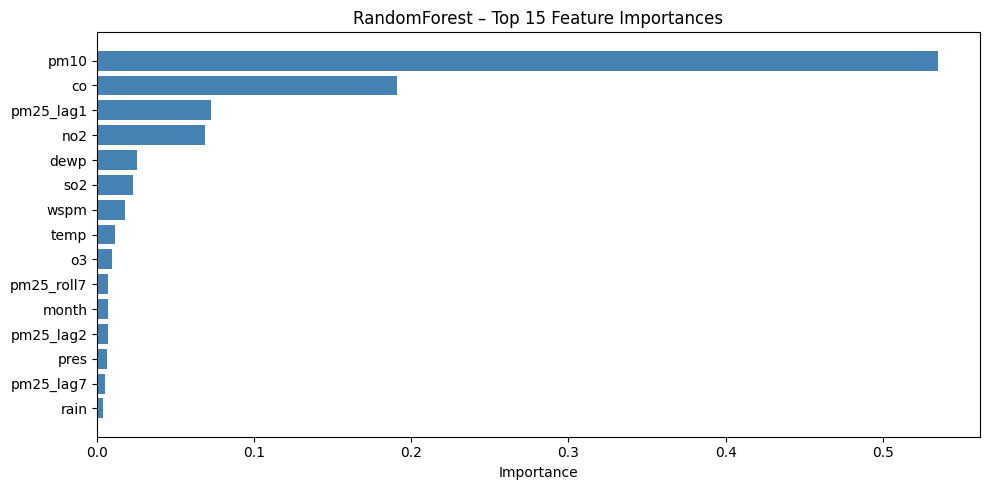

   feature  importance
      pm10    0.535171
        co    0.190687
 pm25_lag1    0.072779
       no2    0.068993
      dewp    0.025133
       so2    0.022902
      wspm    0.017539
      temp    0.011442
        o3    0.009571
pm25_roll7    0.007034
     month    0.006853
 pm25_lag2    0.006825
      pres    0.006028
 pm25_lag7    0.005007
      rain    0.003512


In [ ]:
### Modell verstehen – Feature Importance

# Feature-Namen nach One-Hot-Encoding auslesen
ohe_features = list(
    rf_model.named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)
all_feature_names = ohe_features + numeric_features

importances = rf_model.named_steps["regressor"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": all_feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="steelblue")
ax.set_title("RandomForest – Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

In [ ]:
### Finales Modell auswählen und Submission erzeugen

scores = {
    "LinearRegression": linear_valid_mse,
    "Regularisiert":    regularized_linear_valid_mse,
    "RandomForest":     rf_valid_mse,
    "HGB":              hgb_valid_mse,
}
best_label = min(scores, key=scores.get)
print(f"Bestes Modell: {best_label} (MSE: {scores[best_label]:.3f})")

if best_label == "HGB":
    final_model = hgb_model
elif best_label == "RandomForest":
    final_model = rf_model
elif best_label == "Regularisiert":
    final_model = regularized_linear_model
else:
    final_model = linear_model

final_model.fit(train[feature_columns], train["pm25"])
test_pred_final = final_model.predict(test[feature_columns])

predictions_by_id = pd.Series(test_pred_final, index=test["id"])
submission = sample_submission[["id"]].copy()
raw_pred = predictions_by_id.reindex(submission["id"]).to_numpy()
min_pm25 = float(train["pm25"].min())
submission["pm25"] = np.round(np.clip(raw_pred, a_min=min_pm25, a_max=None), 3)

submission.to_csv(output_path, index=False)
print("Submission geschrieben:", output_path)
print("Shape:", submission.shape)
submission.head()

Bestes Modell: LinearRegression (MSE: 487.229)
Submission geschrieben: submission.csv
Shape: (2845, 2)


,id,pm25
0,Aotizhongxin_2016-07-01,3.000
1,Changping_2016-07-01,3.000
2,Dingling_2016-07-01,3.000
3,Dongsi_2016-07-01,7.763
4,Guanyuan_2016-07-01,5.036
